In [ ]:
!pip install monai[all] -q


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.2/47.2 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.5/266.5 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 71.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.9/80.9 MB 12.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.8/67.8 MB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.0/28.0 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.2/57.2 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 77.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.9/15.9 MB 109.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9

In [ ]:
# Import libraries
import os
import glob
import re
import numpy as np
from typing import Dict, List
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

import monai
from monai.transforms import (
    Compose, LoadImaged, EnsureChannelFirstd, Orientationd, Spacingd,
    ScaleIntensityRanged, CropForegroundd, Resized, Lambdad, EnsureTyped,
    RandRotated, RandFlipd, RandZoomd, MapTransform
)
from monai.data import CacheDataset
from monai.networks.nets import UNet
from monai.losses import DiceCELoss
from monai.metrics import DiceMetric
from monai.inferers import sliding_window_inference

print(f"PyTorch version: {torch.__version__}")
print(f"MONAI version: {monai.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

<frozen importlib._bootstrap_external>:1301: FutureWarning: The cuda.cudart module is deprecated and will be removed in a future release, please switch to use the cuda.bindings.runtime module instead.


PyTorch version: 2.9.0+cu126
MONAI version: 1.5.1
CUDA available: True
Using device: cuda


In [ ]:
# Custom debug transform to print tensor shapes
class DebugPrintShapeD(MapTransform):
    def __init__(self, keys, prefix="Debug"):
        super().__init__(keys)
        self.prefix = prefix

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            if key in d:
                print(f"{self.prefix} - {key}: shape={d[key].shape}, dtype={d[key].dtype}")
        return d

In [ ]:
# Define data paths
image_dir = "/content/drive/MyDrive/nasalseg/images"
label_dir = "/content/drive/MyDrive/nasalseg/labels"

# Gather all image and label paths
image_paths = sorted(glob.glob(os.path.join(image_dir, "*.nrrd")))
label_paths = sorted(glob.glob(os.path.join(label_dir, "*.nrrd")))

print(f"Found {len(image_paths)} images and {len(label_paths)} labels")

Found 129 images and 129 labels


In [ ]:
# Extract patient IDs and pair images with labels
def extract_patient_id(filepath):
    filename = os.path.basename(filepath)
    match = re.match(r"(P\d+)", filename)
    if match:
        return match.group(1)
    return None

# Create dictionary mapping patient IDs to label paths
label_dict = {}
for label_path in label_paths:
    patient_id = extract_patient_id(label_path)
    if patient_id:
        label_dict[patient_id] = label_path

# Pair images with corresponding labels
data_dicts_corrected = []
for image_path in image_paths:
    patient_id = extract_patient_id(image_path)
    if patient_id and patient_id in label_dict:
        data_dicts_corrected.append({
            "image": image_path,
            "label": label_dict[patient_id]
        })

print(f"Successfully paired {len(data_dicts_corrected)} image-label pairs")

# Verify file paths and check for issues
print("\nVerifying file paths:")
for i, pair in enumerate(data_dicts_corrected[:3]):
    img_path = pair['image']
    lbl_path = pair['label']
    print(f"\nSample {i+1}:")
    print(f"  Image: {os.path.basename(img_path)}")
    print(f"  Label: {os.path.basename(lbl_path)}")
    print(f"  Image exists: {os.path.exists(img_path)}")
    print(f"  Label exists: {os.path.exists(lbl_path)}")
    print(f"  Image full path: {img_path}")
    print(f"  Label full path: {lbl_path}")

Successfully paired 129 image-label pairs

Verifying file paths:

Sample 1:
  Image: P002_img.nrrd
  Label: P002_seg.nrrd
  Image exists: True
  Label exists: True
  Image full path: /content/drive/MyDrive/nasalseg/images/P002_img.nrrd
  Label full path: /content/drive/MyDrive/nasalseg/labels/P002_seg.nrrd

Sample 2:
  Image: P003_img.nrrd
  Label: P003_seg.nrrd
  Image exists: True
  Label exists: True
  Image full path: /content/drive/MyDrive/nasalseg/images/P003_img.nrrd
  Label full path: /content/drive/MyDrive/nasalseg/labels/P003_seg.nrrd

Sample 3:
  Image: P004_img.nrrd
  Label: P004_seg.nrrd
  Image exists: True
  Label exists: True
  Image full path: /content/drive/MyDrive/nasalseg/images/P004_img.nrrd
  Label full path: /content/drive/MyDrive/nasalseg/labels/P004_seg.nrrd


In [ ]:
# Split data into training and validation sets
train_files, val_files = train_test_split(
    data_dicts_corrected,
    test_size=0.2,
    random_state=42
)

print(f"Training samples: {len(train_files)}")
print(f"Validation samples: {len(val_files)}")

Training samples: 103
Validation samples: 26


In [ ]:
spatial_size = (192, 240, 64)
print(f"Maximum spatial size (for padding): {spatial_size}")


Maximum spatial size (for padding): (192, 240, 64)


In [ ]:
import nrrd
import numpy as np
from monai.transforms import MapTransform
from monai.data import MetaTensor
from monai.transforms import SpatialPadd
from monai.transforms import CenterSpatialCropd

# Custom NRRD loader that uses pynrrd directly with proper metadata
class LoadNrrd(MapTransform):
    def __init__(self, keys):
        super().__init__(keys)

    def __call__(self, data):
        d = dict(data)
        for key in self.keys:
            filepath = d[key]
            # Read with pynrrd
            array, header = nrrd.read(filepath)

            # Convert to float32 for processing
            array = array.astype(np.float32)

            # NRRD arrays are already in the correct format
            # Just ensuring it's a MetaTensor with proper metadata
            meta_dict = {
                "filename_or_obj": filepath,
                "spatial_shape": array.shape,
                "original_channel_dim": "no_channel",  # Indicate no channel dimension yet
            }

            # Create MetaTensor with metadata
            d[key] = MetaTensor(array, meta=meta_dict)
        return d

train_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=500, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=spatial_size),
    SpatialPadd(keys=["image", "label"], spatial_size=spatial_size, mode="constant"),
    DebugPrintShapeD(keys=["image", "label"], prefix="[Train] After Padding"),
    Lambdad(keys=["label"], func=lambda x: (x > 0).astype(np.float32)),
    RandRotated(keys=["image", "label"], range_x=0.15, range_y=0.15, range_z=0.15, prob=0.5, keep_size=True, mode=("bilinear", "nearest")),
    RandFlipd(keys=["image", "label"], spatial_axis=[0, 1, 2], prob=0.10),
    RandZoomd(keys=["image", "label"], min_zoom=0.9, max_zoom=1.1, prob=0.5, mode=("bilinear", "nearest")),
    EnsureTyped(keys=["image", "label"], dtype=torch.float32),
])

print("Training transforms defined with padding")


# Define validation transformations with padding instead of resizing
val_transforms = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    Orientationd(keys=["image", "label"], axcodes="RAS"),
    Spacingd(keys=["image", "label"], pixdim=(1.0, 1.0, 1.0), mode=("bilinear", "nearest")),
    ScaleIntensityRanged(keys=["image"], a_min=-1000, a_max=500, b_min=0.0, b_max=1.0, clip=True),
    CropForegroundd(keys=["image", "label"], source_key="image"),
    CenterSpatialCropd(keys=["image", "label"], roi_size=spatial_size), # Added this line
    SpatialPadd(keys=["image", "label"], spatial_size=spatial_size, mode="constant"),
    DebugPrintShapeD(keys=["image", "label"], prefix="[Val] After Padding"),
    Lambdad(keys=["label"], func=lambda x: (x > 0).astype(np.float32)),
    EnsureTyped(keys=["image", "label"], dtype=torch.float32),
])

print("Validation transforms defined with padding")

Training transforms defined with padding
Validation transforms defined with padding


monai.transforms.spatial.dictionary Orientationd.__init__:labels: Current default value of argument `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` was changed in version None from `labels=(('L', 'R'), ('P', 'A'), ('I', 'S'))` to `labels=None`. Default value changed to None meaning that the transform now uses the 'space' of a meta-tensor, if applicable, to determine appropriate axis labels.


In [ ]:

# Create cached datasets
!pip install pynrrd
print("Creating cached datasets...")
train_ds = CacheDataset(
    data=train_files,
    transform=train_transforms,
    cache_rate=1.0,
    num_workers=2
)

val_ds = CacheDataset(
    data=val_files,
    transform=val_transforms,
    cache_rate=1.0,
    num_workers=2
)

print(f"Training dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")

Creating cached datasets...


Loading dataset:   1%|          | 1/103 [00:00<00:24,  4.17it/s]

[Train] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32


Loading dataset:   3%|▎         | 3/103 [00:00<00:14,  6.99it/s]

[Train] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Train] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32


...

[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32


Loading dataset:  96%|█████████▌| 25/26 [00:03<00:00,  7.80it/s]

[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32


Loading dataset: 100%|██████████| 26/26 [00:03<00:00,  6.93it/s]

[Val] After Padding - image: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
[Val] After Padding - label: shape=torch.Size([1, 192, 240, 64]), dtype=torch.float32
Training dataset size: 103
Validation dataset size: 26


In [ ]:
# Create data loaders
batch_size = 1  # Adjust based on your GPU memory, I'm working on colab so its fine

train_loader = DataLoader(
    train_ds,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

In [ ]:
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    dropout=0.1,
    norm="batch"
).to(device)

print(f"Model created and moved to {device}")
print(f"Number of parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Output channels: {model.out_channels} (binary segmentation)")

Model created and moved to cuda
Number of parameters: 4,807,968
Output channels: 1 (binary segmentation)


In [ ]:
# Setup training configuration with scheduler
from monai.losses import DiceLoss
from torch.nn import BCEWithLogitsLoss
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Define combined loss function for binary segmentation
class DiceBCELoss(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.dice = DiceLoss(sigmoid=True, squared_pred=True)
        self.bce = BCEWithLogitsLoss()

    def forward(self, pred, target):
        return self.dice(pred, target) + self.bce(pred, target)

loss_function = DiceBCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5, weight_decay=1e-5)

# Add learning rate scheduler
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='max',  # maximize Dice score
    factor=0.5,  # reduce LR by half
    patience=5,  # wait 5 epochs
    min_lr=1e-6
)

scaler = torch.cuda.amp.GradScaler() if torch.cuda.is_available() else None
dice_metric = DiceMetric(include_background=False, reduction="mean")

max_epochs = 100  # Increased for proper training started with 50. For some reason its fast
val_interval = 2
best_metric = -1
best_metric_epoch = -1
patience_counter = 0
early_stop_patience = 15  # Stop if no improvement for 15 epochs

print("Training configuration:")
print(f"  Loss function: Dice + BCE (binary segmentation)")
print(f"  Optimizer: Adam (lr=1e-5, weight_decay=1e-5)")
print(f"  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")
print(f"  Max epochs: {max_epochs}")
print(f"  Validation interval: {val_interval}")
print(f"  Early stopping patience: {early_stop_patience}")
print(f"  Mixed precision: {scaler is not None}")

Training configuration:
  Loss function: Dice + BCE (binary segmentation)
  Optimizer: Adam (lr=1e-4, weight_decay=1e-5)
  Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)
  Max epochs: 100
  Validation interval: 2
  Early stopping patience: 15
  Mixed precision: True


`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.


In [ ]:
import torch
import numpy as np
from monai.metrics import DiceMetric, HausdorffDistanceMetric


# METRIC CALCULATION FUNCTIONS


def calculate_iou(pred, target, smooth=1e-6):
    """Intersection over Union (IoU) / Jaccard Index"""
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    intersection = (pred * target).sum()
    union = pred.sum() + target.sum() - intersection

    iou = (intersection + smooth) / (union + smooth)
    return iou.item()

def calculate_sensitivity(pred, target, smooth=1e-6):
    """Sensitivity / Recall / True Positive Rate"""
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    true_positive = (pred * target).sum()
    false_negative = ((1 - pred) * target).sum()

    sensitivity = (true_positive + smooth) / (true_positive + false_negative + smooth)
    return sensitivity.item()

def calculate_specificity(pred, target, smooth=1e-6):
    """Specificity / True Negative Rate"""
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    true_negative = ((1 - pred) * (1 - target)).sum()
    false_positive = (pred * (1 - target)).sum()

    specificity = (true_negative + smooth) / (true_negative + false_positive + smooth)
    return specificity.item()

def calculate_precision(pred, target, smooth=1e-6):
    """Precision / Positive Predictive Value"""
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    true_positive = (pred * target).sum()
    false_positive = (pred * (1 - target)).sum()

    precision = (true_positive + smooth) / (true_positive + false_positive + smooth)
    return precision.item()

def calculate_f1_score(pred, target, smooth=1e-6):
    """F1 Score (Harmonic mean of precision and recall)"""
    precision = calculate_precision(pred, target, smooth)
    sensitivity = calculate_sensitivity(pred, target, smooth)

    f1 = 2 * (precision * sensitivity) / (precision + sensitivity + smooth)
    return f1

def calculate_volume_similarity(pred, target, smooth=1e-6):
    """Volume Similarity Coefficient"""
    pred = (pred > 0.5).float()
    target = (target > 0.5).float()

    pred_vol = pred.sum()
    target_vol = target.sum()

    vs = 1 - abs(pred_vol - target_vol) / (pred_vol + target_vol + smooth)
    return vs.item()

# METRICS TRACKING CLASS


class SegmentationMetrics:
    """Track all segmentation metrics"""

    def __init__(self):
        self.dice_metric = DiceMetric(include_background=False, reduction="mean")
        self.reset()

    def reset(self):
        """Reset all metrics"""
        self.dice_scores = []
        self.iou_scores = []
        self.sensitivity_scores = []
        self.specificity_scores = []
        self.precision_scores = []
        self.f1_scores = []
        self.volume_similarities = []
        self.losses = []

    def update(self, pred, target, loss=None):
        """Update metrics with new batch"""
        # Ensure pred and target are in the right format
        if pred.dim() == 4:  # [B, C, H, W] or [B, 1, H, W, D]
            pred_binary = (pred > 0.5).float()
        else:
            pred_binary = (pred > 0.5).float()

        if target.dim() == 4:
            target_binary = (target > 0.5).float()
        else:
            target_binary = (target > 0.5).float()

        # Calculate metrics
        try:
            dice = self.dice_metric(pred_binary, target_binary).mean().item()
            self.dice_scores.append(dice)
        except:
            pass

        self.iou_scores.append(calculate_iou(pred, target))
        self.sensitivity_scores.append(calculate_sensitivity(pred, target))
        self.specificity_scores.append(calculate_specificity(pred, target))
        self.precision_scores.append(calculate_precision(pred, target))
        self.f1_scores.append(calculate_f1_score(pred, target))
        self.volume_similarities.append(calculate_volume_similarity(pred, target))

        if loss is not None:
            self.losses.append(loss)

    def get_averages(self):
        """Get average of all metrics"""
        return {
            'dice': np.mean(self.dice_scores) if self.dice_scores else 0,
            'iou': np.mean(self.iou_scores) if self.iou_scores else 0,
            'sensitivity': np.mean(self.sensitivity_scores) if self.sensitivity_scores else 0,
            'specificity': np.mean(self.specificity_scores) if self.specificity_scores else 0,
            'precision': np.mean(self.precision_scores) if self.precision_scores else 0,
            'f1': np.mean(self.f1_scores) if self.f1_scores else 0,
            'volume_similarity': np.mean(self.volume_similarities) if self.volume_similarities else 0,
            'loss': np.mean(self.losses) if self.losses else 0
        }

    def print_summary(self, prefix=""):
        """Print metrics summary"""
        metrics = self.get_averages()
        print(f"\n{prefix} Metrics Summary:")
        print(f"  Loss:              {metrics['loss']:.4f}")
        print(f"  Dice Score:        {metrics['dice']:.4f}")
        print(f"  IoU:               {metrics['iou']:.4f}")
        print(f"  Sensitivity:       {metrics['sensitivity']:.4f}")
        print(f"  Specificity:       {metrics['specificity']:.4f}")
        print(f"  Precision:         {metrics['precision']:.4f}")
        print(f"  F1 Score:          {metrics['f1']:.4f}")
        print(f"  Volume Similarity: {metrics['volume_similarity']:.4f}")

print("Metric functions and SegmentationMetrics class defined")

Metric functions and SegmentationMetrics class defined



Epoch 1/100


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


  Step 10/103 | Loss: 1.6471 | Dice: 0.0456 | IoU: 0.0234
  Step 20/103 | Loss: 1.6106 | Dice: 0.0493 | IoU: 0.0253
  Step 30/103 | Loss: 1.5983 | Dice: 0.0538 | IoU: 0.0277
  Step 40/103 | Loss: 1.5739 | Dice: 0.0651 | IoU: 0.0338
  Step 50/103 | Loss: 1.5115 | Dice: 0.0786 | IoU: 0.0412
  Step 60/103 | Loss: 1.5627 | Dice: 0.0900 | IoU: 0.0476
  Step 70/103 | Loss: 1.5613 | Dice: 0.0996 | IoU: 0.0530
  Step 80/103 | Loss: 1.5675 | Dice: 0.1072 | IoU: 0.0574
  Step 90/103 | Loss: 1.5762 | Dice: 0.1168 | IoU: 0.0630
  Step 100/103 | Loss: 1.5361 | Dice: 0.1275 | IoU: 0.0693

──────────────────────────────────────────────────────────────────────

Training Metrics Summary:
  Loss:              1.5737
  Dice Score:        0.1310
  IoU:               0.0714
  Sensitivity:       0.5227
  Specificity:       0.8273
  Precision:         0.0766
  F1 Score:          0.1310
  Volume Similarity: 0.2416
──────────────────────────────────────────────────────────────────────

Epoch 2/100
  Step 10/10

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



──────────────────────────────────────────────────────────────────────

Validation Metrics Summary:
  Loss:              nan
  Dice Score:        0.4714
  IoU:               0.3104
  Sensitivity:       0.9620
  Specificity:       0.9524
  Precision:         0.3147
  F1 Score:          0.4714
  Volume Similarity: 0.4911
──────────────────────────────────────────────────────────────────────

Current learning rate: 1.00e-04

New best model saved!
   Dice: 0.4714
   Sensitivity: 0.9620
   Specificity: 0.9524
   IoU: 0.3104

Epoch 3/100
  Step 10/103 | Loss: 1.5258 | Dice: 0.4370 | IoU: 0.2838
  Step 20/103 | Loss: 1.5428 | Dice: 0.3946 | IoU: 0.2501
  Step 30/103 | Loss: 1.4762 | Dice: 0.3998 | IoU: 0.2529
  Step 40/103 | Loss: 1.5237 | Dice: 0.3999 | IoU: 0.2526
  Step 50/103 | Loss: 1.4381 | Dice: 0.3967 | IoU: 0.2504
  Step 60/103 | Loss: 1.5103 | Dice: 0.3972 | IoU: 0.2506
  Step 70/103 | Loss: 1.5053 | Dice: 0.4037 | IoU: 0.2562
  Step 80/103 | Loss: 1.5069 | Dice: 0.4086 | IoU: 0.26

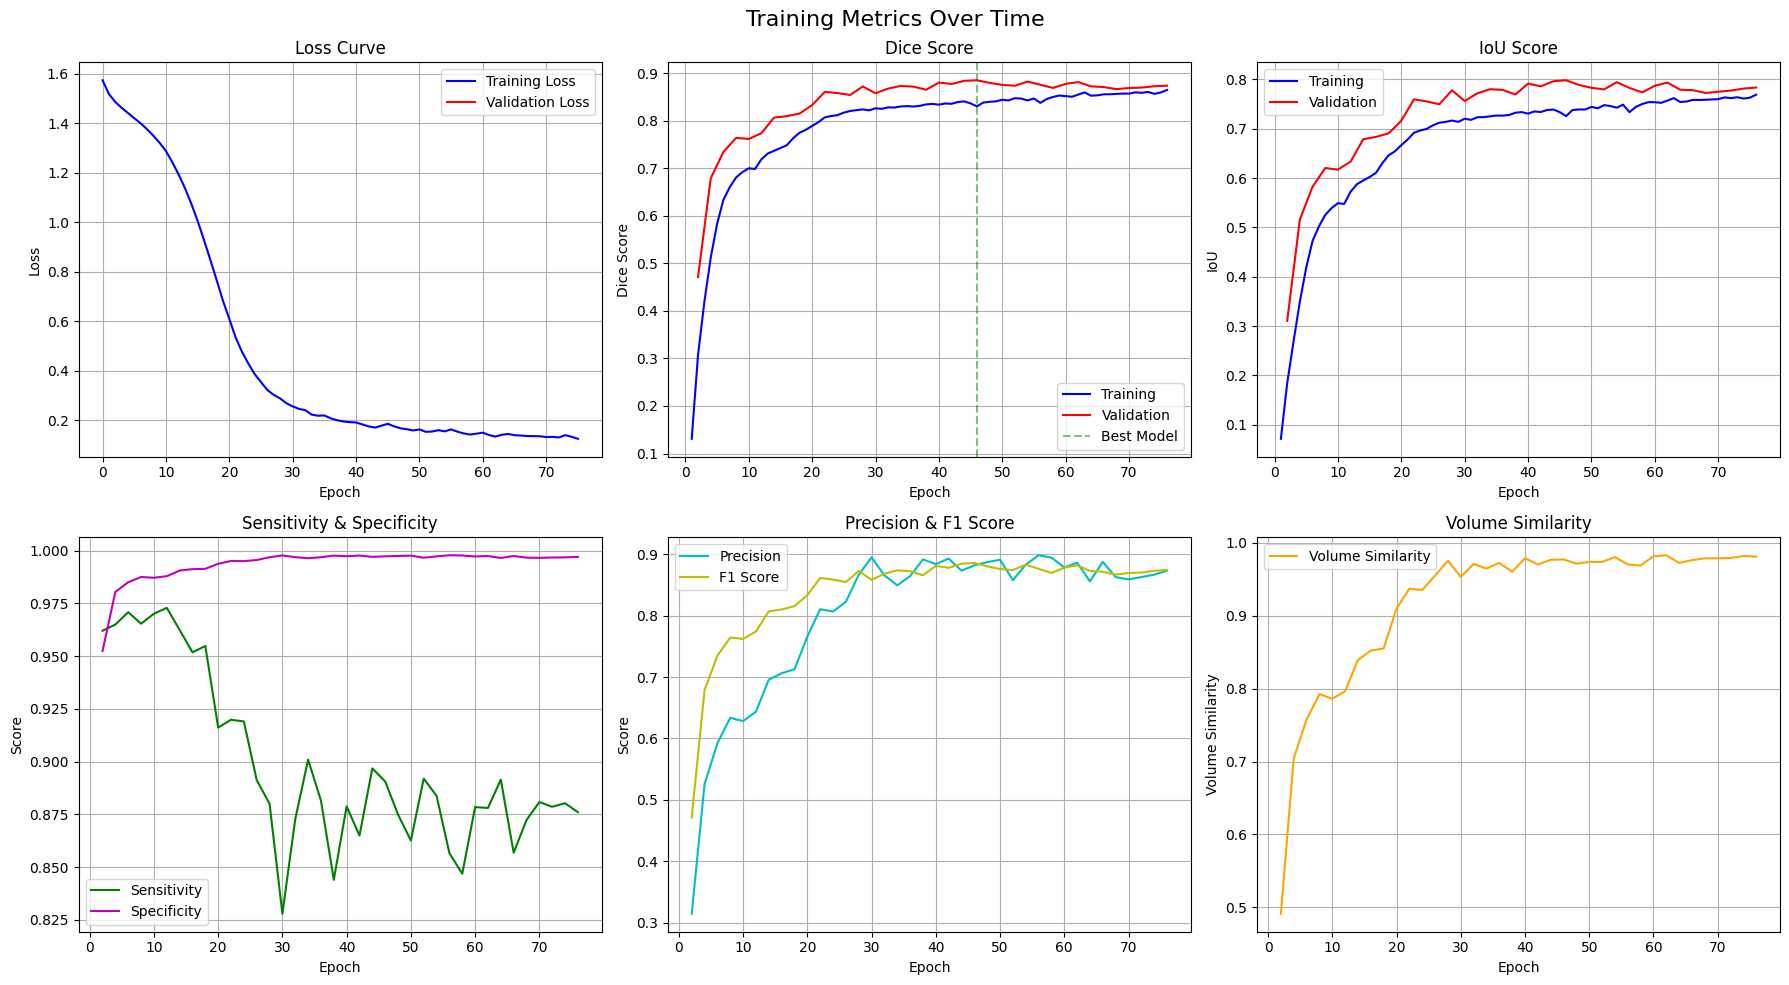


Training metrics plot saved as 'training_metrics.png'


In [ ]:
# Initialize metrics trackers
train_metrics = SegmentationMetrics()
val_metrics = SegmentationMetrics()

# Training and validation loop
epoch_loss_values = []
epoch_train_metrics = []
epoch_val_metrics = []

for epoch in range(max_epochs):
    print(f"\n{'='*70}")
    print(f"Epoch {epoch + 1}/{max_epochs}")
    print(f"{'='*70}")


    # Training Phase

    model.train()
    train_metrics.reset()
    epoch_loss = 0
    step = 0

    for batch_data in train_loader:
        step += 1
        inputs, labels = batch_data["image"].to(device), batch_data["label"].to(device)

        optimizer.zero_grad()

        if scaler is not None:
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss = loss_function(outputs, labels)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = model(inputs)
            loss = loss_function(outputs, labels)
            loss.backward()
            optimizer.step()

        epoch_loss += loss.item()

        # Update metrics (applied sigmoid for binary segmentation)
        with torch.no_grad():
            outputs_sigmoid = torch.sigmoid(outputs)
            train_metrics.update(outputs_sigmoid, labels, loss.item())

        if step % 10 == 0:
            current_metrics = train_metrics.get_averages()
            print(f"  Step {step}/{len(train_loader)} | "
                  f"Loss: {loss.item():.4f} | "
                  f"Dice: {current_metrics['dice']:.4f} | "
                  f"IoU: {current_metrics['iou']:.4f}")

    # Training epoch summary
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    train_summary = train_metrics.get_averages()
    epoch_train_metrics.append(train_summary)

    print(f"\n{'─'*70}")
    train_metrics.print_summary("Training")
    print(f"{'─'*70}")


    # Validation Phase

    if (epoch + 1) % val_interval == 0:
        print(f"\nRunning validation...")
        model.eval()
        val_metrics.reset()

        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

                if scaler is not None:
                    with torch.cuda.amp.autocast():
                        val_outputs = model(val_inputs)
                else:
                    val_outputs = model(val_inputs)

                # Calculate validation loss
                val_loss = loss_function(val_outputs, val_labels)

                # Apply sigmoid for metrics
                val_outputs_sigmoid = torch.sigmoid(val_outputs)

                # Update metrics
                val_metrics.update(val_outputs_sigmoid, val_labels, val_loss.item())

        # Validation summary
        val_summary = val_metrics.get_averages()
        epoch_val_metrics.append(val_summary)

        print(f"\n{'─'*70}")
        val_metrics.print_summary("Validation")
        print(f"{'─'*70}")

        # Update learning rate scheduler
        current_dice = val_summary['dice']
        scheduler.step(current_dice)
        current_lr = optimizer.param_groups[0]['lr']
        print(f"\nCurrent learning rate: {current_lr:.2e}")

        # Check for best model and early stopping
        if current_dice > best_metric:
            best_metric = current_dice
            best_metric_epoch = epoch + 1
            patience_counter = 0  # Reset patience

            # Save model with all metrics
            torch.save({
                'epoch': epoch + 1,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'scheduler_state_dict': scheduler.state_dict(),
                'dice_score': best_metric,
                'all_metrics': val_summary,
                'train_metrics': train_summary
            }, "best_metric_model.pth")

            print(f"\nNew best model saved!")
            print(f"   Dice: {best_metric:.4f}")
            print(f"   Sensitivity: {val_summary['sensitivity']:.4f}")
            print(f"   Specificity: {val_summary['specificity']:.4f}")
            print(f"   IoU: {val_summary['iou']:.4f}")
        else:
            patience_counter += 1
            print(f"\nNo improvement. Patience: {patience_counter}/{early_stop_patience}")

            if patience_counter >= early_stop_patience:
                print(f"\nEarly stopping triggered at epoch {epoch + 1}")
                print(f"Best model was at epoch {best_metric_epoch} with Dice: {best_metric:.4f}")
                break

print(f"\n{'='*70}")
print(f"Training Completed!")
print(f"{'='*70}")
print(f"Best Dice Score: {best_metric:.4f} at epoch {best_metric_epoch}")
if patience_counter >= early_stop_patience:
    print(f"Training stopped early due to no improvement for {early_stop_patience} epochs")


# Final Metrics Summary

print(f"\n{'='*70}")
print("Final Best Model Metrics:")
print(f"{'='*70}")
best_epoch_idx = best_metric_epoch - 1
if best_epoch_idx < len(epoch_val_metrics):
    best_metrics = epoch_val_metrics[best_epoch_idx // val_interval]
    for metric_name, value in best_metrics.items():
        if metric_name != 'loss':
            print(f"  {metric_name.capitalize():20s}: {value:.4f}")


# Plot Training Metrics

import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Training Metrics Over Time', fontsize=16)

# Loss
axes[0, 0].plot(epoch_loss_values, 'b-', label='Training Loss')
val_losses = [m['loss'] for m in epoch_val_metrics]
val_epochs = [(i * val_interval) + val_interval for i in range(len(val_losses))]
axes[0, 0].plot(val_epochs, val_losses, 'r-', label='Validation Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Dice Score
train_dice = [m['dice'] for m in epoch_train_metrics]
val_dice = [m['dice'] for m in epoch_val_metrics]
axes[0, 1].plot(range(1, len(train_dice) + 1), train_dice, 'b-', label='Training')
axes[0, 1].plot(val_epochs, val_dice, 'r-', label='Validation')
axes[0, 1].axvline(x=best_metric_epoch, color='g', linestyle='--', alpha=0.5, label='Best Model')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Dice Score')
axes[0, 1].set_title('Dice Score')
axes[0, 1].legend()
axes[0, 1].grid(True)

# IoU
train_iou = [m['iou'] for m in epoch_train_metrics]
val_iou = [m['iou'] for m in epoch_val_metrics]
axes[0, 2].plot(range(1, len(train_iou) + 1), train_iou, 'b-', label='Training')
axes[0, 2].plot(val_epochs, val_iou, 'r-', label='Validation')
axes[0, 2].set_xlabel('Epoch')
axes[0, 2].set_ylabel('IoU')
axes[0, 2].set_title('IoU Score')
axes[0, 2].legend()
axes[0, 2].grid(True)

# Sensitivity & Specificity
val_sens = [m['sensitivity'] for m in epoch_val_metrics]
val_spec = [m['specificity'] for m in epoch_val_metrics]
axes[1, 0].plot(val_epochs, val_sens, 'g-', label='Sensitivity')
axes[1, 0].plot(val_epochs, val_spec, 'm-', label='Specificity')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Score')
axes[1, 0].set_title('Sensitivity & Specificity')
axes[1, 0].legend()
axes[1, 0].grid(True)

# Precision & F1
val_prec = [m['precision'] for m in epoch_val_metrics]
val_f1 = [m['f1'] for m in epoch_val_metrics]
axes[1, 1].plot(val_epochs, val_prec, 'c-', label='Precision')
axes[1, 1].plot(val_epochs, val_f1, 'y-', label='F1 Score')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Score')
axes[1, 1].set_title('Precision & F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

# Volume Similarity
val_vs = [m['volume_similarity'] for m in epoch_val_metrics]
axes[1, 2].plot(val_epochs, val_vs, 'orange', label='Volume Similarity')
axes[1, 2].set_xlabel('Epoch')
axes[1, 2].set_ylabel('Volume Similarity')
axes[1, 2].set_title('Volume Similarity')
axes[1, 2].legend()
axes[1, 2].grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nTraining metrics plot saved as 'training_metrics.png'")

In [ ]:

#POST-TRAINING VISUALIZATION PIPELINE


import shutil
import json
from datetime import datetime
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
import numpy as np
import os

# Create timestamped folder for this training run
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
save_dir = f"/content/drive/MyDrive/nasalseg/training_runs/run_{timestamp}"
os.makedirs(save_dir, exist_ok=True)

print("="*70)
print("COMPLETE POST-TRAINING PIPELINE")
print("="*70)
print(f"Save directory: {save_dir}")


# Save Training Artifacts


print("\n" + "="*70)
print(" SAVING BASIC TRAINING ARTIFACTS")
print("="*70)

# Save best model checkpoint
print("Saving model checkpoint...")
shutil.copy("best_metric_model.pth", f"{save_dir}/best_metric_model.pth")
print(f" Saved to {save_dir}/best_metric_model.pth")

# Save training plots
print("Saving training plots...")
shutil.copy("training_metrics.png", f"{save_dir}/training_metrics.png")
print(f" Saved to {save_dir}/training_metrics.png")

# Save training history
print("Saving training history...")
training_history = {
    'timestamp': timestamp,
    'best_epoch': best_metric_epoch,
    'best_dice': best_metric,
    'total_epochs_trained': len(epoch_loss_values),
    'early_stopped': patience_counter >= early_stop_patience if 'patience_counter' in locals() else False,
    'epoch_losses': epoch_loss_values,
    'train_metrics_history': epoch_train_metrics,
    'val_metrics_history': epoch_val_metrics,
    'hyperparameters': {
        'max_epochs': max_epochs,
        'learning_rate': optimizer.param_groups[0]['lr'],
        'batch_size': train_loader.batch_size,
        'spatial_size': spatial_size,
        'val_interval': val_interval,
        'early_stop_patience': early_stop_patience if 'early_stop_patience' in locals() else None,
        'optimizer': 'Adam',
        'loss_function': 'Dice + BCE',
        'scheduler': 'ReduceLROnPlateau' if 'scheduler' in locals() else None
    }
}

with open(f"{save_dir}/training_history.json", 'w') as f:
    json.dump(training_history, f, indent=2)
print(f" Saved to {save_dir}/training_history.json")

# Save model architecture info
print("Saving model info...")
model_info = {
    'model_type': 'UNet',
    'spatial_dims': 3,
    'in_channels': 1,
    'out_channels': 1,
    'channels': [16, 32, 64, 128, 256],
    'total_parameters': sum(p.numel() for p in model.parameters()),
    'trainable_parameters': sum(p.numel() for p in model.parameters() if p.requires_grad)
}

with open(f"{save_dir}/model_info.json", 'w') as f:
    json.dump(model_info, f, indent=2)
print(f" Saved to {save_dir}/model_info.json")

# Basic Evaluation Visuals


print("\n" + "="*70)
print(" GENERATING BASIC EVALUATION VISUALIZATIONS")
print("="*70)

# Load best model
checkpoint = torch.load("best_metric_model.pth", weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Create folder for evaluation visualizations
eval_viz_dir = f"{save_dir}/evaluation_visualizations"
os.makedirs(eval_viz_dir, exist_ok=True)

# Initialize evaluation metrics
eval_metrics = SegmentationMetrics()

print(f"Evaluating on validation set...")

with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        val_inputs, val_labels = val_data["image"].to(device), val_data["label"].to(device)

        # Forward pass
        if scaler is not None:
            with torch.cuda.amp.autocast():
                val_outputs = model(val_inputs)
        else:
            val_outputs = model(val_inputs)

        # Apply sigmoid
        val_outputs_sigmoid = torch.sigmoid(val_outputs)
        val_outputs_binary = (val_outputs_sigmoid > 0.5).float()

        # Update metrics
        eval_metrics.update(val_outputs_sigmoid, val_labels)

        # Save visualizations for first 5 samples
        if i < 5:
            slice_idx = spatial_size[2] // 2
            img_slice = val_inputs[0, 0, :, :, slice_idx].cpu().numpy()
            label_slice = val_labels[0, 0, :, :, slice_idx].cpu().numpy()
            pred_slice = val_outputs_binary[0, 0, :, :, slice_idx].cpu().numpy()

            fig, axes = plt.subplots(1, 4, figsize=(20, 5))

            axes[0].imshow(img_slice, cmap='gray')
            axes[0].set_title('Input Image', fontsize=12, fontweight='bold')
            axes[0].axis('off')

            axes[1].imshow(label_slice, cmap='Reds', alpha=0.8)
            axes[1].set_title('Ground Truth', fontsize=12, fontweight='bold')
            axes[1].axis('off')

            axes[2].imshow(pred_slice, cmap='Blues', alpha=0.8)
            axes[2].set_title('Prediction', fontsize=12, fontweight='bold')
            axes[2].axis('off')

            axes[3].imshow(img_slice, cmap='gray')
            axes[3].imshow(label_slice, cmap='Reds', alpha=0.3)
            axes[3].imshow(pred_slice, cmap='Blues', alpha=0.3)
            axes[3].set_title('Overlay (Red=GT, Blue=Pred)', fontsize=12, fontweight='bold')
            axes[3].axis('off')

            plt.tight_layout()
            plt.savefig(f"{eval_viz_dir}/sample_{i+1}.png", dpi=150, bbox_inches='tight')
            plt.close()

# Save evaluation results
eval_results = eval_metrics.get_averages()
with open(f"{save_dir}/evaluation_results.json", 'w') as f:
    json.dump(eval_results, f, indent=2)

print(f"Evaluation visualizations saved to {eval_viz_dir}")
print(f"Evaluation results saved")

#Gradcam Visualization


print("\n" + "="*70)
print(" GENERATING GRADCAM VISUALIZATIONS")
print("="*70)

class SegmentationGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        # Register hooks
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output.detach()

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate_cam(self, input_tensor, target_mask=None):
        self.model.eval()

        # Forward pass
        output = self.model(input_tensor)
        output_sigmoid = torch.sigmoid(output)

        # Backward pass
        self.model.zero_grad()
        if target_mask is not None:
            loss = F.binary_cross_entropy(output_sigmoid, target_mask)
        else:
            loss = output_sigmoid.sum()
        loss.backward()

        # Generate CAM
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3, 4])

        for i in range(self.activations.shape[1]):
            self.activations[:, i, :, :, :] *= pooled_gradients[i]

        # Average across channels
        cam = torch.mean(self.activations, dim=1).squeeze().cpu().numpy()

        # Normalize
        cam = np.maximum(cam, 0)
        cam = cam / (cam.max() + 1e-8)

        return cam, output_sigmoid

# Get target layer (last encoder layer)
try:
    # Access the encoder's last layer
    if hasattr(model, 'model'):
        # Try different access patterns for MONAI UNet
        try:
            target_layer = list(model.model[0].children())[-1]
        except:
            target_layer = model.model[0]
    else:
        # Fallback to direct model access
        target_layer = list(model.children())[0]

    gradcam = SegmentationGradCAM(model, target_layer)

    gradcam_dir = f"{save_dir}/gradcam_visualizations"
    os.makedirs(gradcam_dir, exist_ok=True)

    for i, val_data in enumerate(val_loader):
        if i >= 3:
            break

        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)

        # Generate GradCAM
        val_inputs.requires_grad = True
        cam, pred = gradcam.generate_cam(val_inputs, val_labels)

        # Visualize middle slice
        slice_idx = spatial_size[2] // 2
        img_slice = val_inputs[0, 0, :, :, slice_idx].cpu().detach().numpy()
        label_slice = val_labels[0, 0, :, :, slice_idx].cpu().numpy()
        pred_slice = (pred[0, 0, :, :, slice_idx] > 0.5).float().cpu().numpy()
        # CAM might have different spatial size, use its actual size
        cam_slice_idx = min(slice_idx, cam.shape[2] - 1)
        cam_slice_raw = cam[:, :, cam_slice_idx]

        # Resize CAM to match input size for better visualization
        from scipy.ndimage import zoom
        zoom_factors = (img_slice.shape[0] / cam_slice_raw.shape[0],
                       img_slice.shape[1] / cam_slice_raw.shape[1])
        cam_slice = zoom(cam_slice_raw, zoom_factors, order=1)

        # Create visualization
        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        # Row 1: Original views
        axes[0, 0].imshow(img_slice, cmap='gray')
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(label_slice, cmap='Reds', alpha=0.8)
        axes[0, 1].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[0, 1].axis('off')

        axes[0, 2].imshow(pred_slice, cmap='Blues', alpha=0.8)
        axes[0, 2].set_title('Prediction', fontsize=14, fontweight='bold')
        axes[0, 2].axis('off')

        # Row 2: GradCAM visualizations
        im = axes[1, 0].imshow(cam_slice, cmap='jet')
        axes[1, 0].set_title('GradCAM Heatmap', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')
        plt.colorbar(im, ax=axes[1, 0], fraction=0.046)

        axes[1, 1].imshow(img_slice, cmap='gray')
        axes[1, 1].imshow(cam_slice, cmap='jet', alpha=0.5)
        axes[1, 1].set_title('GradCAM Overlay', fontsize=14, fontweight='bold')
        axes[1, 1].axis('off')

        axes[1, 2].imshow(img_slice, cmap='gray')
        axes[1, 2].imshow(label_slice, cmap='Reds', alpha=0.3)
        axes[1, 2].imshow(cam_slice, cmap='jet', alpha=0.3)
        axes[1, 2].set_title('Full Overlay\n(Red=GT, Hot=Attention)', fontsize=14, fontweight='bold')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.savefig(f"{gradcam_dir}/gradcam_sample_{i+1}.png", dpi=150, bbox_inches='tight')
        plt.close()

    print(f"GradCAM visualizations saved to {gradcam_dir}")

except Exception as e:
    print(f" GradCAM generation failed: {e}")
    print("  Continuing with other visualizations...")

# Feature Map Visualization

print("\n" + "="*70)
print(" GENERATING FEATURE MAP VISUALIZATIONS")
print("="*70)

def visualize_feature_maps(model, input_tensor, save_path):
    """Visualize intermediate feature maps"""

    activations = []

    def hook_fn(module, input, output):
        activations.append(output.detach())

    # Register hooks on encoder layers
    hooks = []
    try:
        # Get encoder layers
        if hasattr(model, 'model'):
            encoder = model.model[0]
            # Convert to list if needed
            if hasattr(encoder, 'children'):
                encoder_layers = list(encoder.children())
            else:
                encoder_layers = [encoder]
        else:
            encoder_layers = list(model.children())[:5]  # First 5 layers. typically encoder

        for layer in encoder_layers:
            hooks.append(layer.register_forward_hook(hook_fn))

        # Forward pass
        model.eval()
        with torch.no_grad():
            _ = model(input_tensor)

        # Remove hooks
        for hook in hooks:
            hook.remove()

        # Visualize feature maps
        num_layers = len(activations)
        fig, axes = plt.subplots(num_layers, 8, figsize=(24, num_layers * 3))
        fig.suptitle('Feature Maps at Different Encoder Layers', fontsize=16, fontweight='bold')

        for layer_idx, activation in enumerate(activations):
            num_channels = min(8, activation.shape[1])
            # Use the actual depth of this activation
            act_slice_idx = activation.shape[4] // 2

            for ch_idx in range(num_channels):
                if num_layers > 1:
                    ax = axes[layer_idx, ch_idx]
                else:
                    ax = axes[ch_idx]

                # Get middle slice using this layer's actual size
                feat_map = activation[0, ch_idx, :, :, act_slice_idx].cpu().numpy()

                ax.imshow(feat_map, cmap='viridis')
                if ch_idx == 0:
                    ax.set_ylabel(f'Layer {layer_idx + 1}', fontsize=12, fontweight='bold')
                if layer_idx == 0:
                    ax.set_title(f'Channel {ch_idx + 1}', fontsize=10)
                ax.axis('off')

        plt.tight_layout()
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        plt.close()

        return True

    except Exception as e:
        print(f"  Error: {e}")
        return False

# Generate feature maps
feature_map_dir = f"{save_dir}/feature_maps"
os.makedirs(feature_map_dir, exist_ok=True)

val_data = next(iter(val_loader))
val_inputs = val_data["image"].to(device)

success = visualize_feature_maps(model, val_inputs, f"{feature_map_dir}/feature_maps.png")
if success:
    print(f"Feature maps saved to {feature_map_dir}")
else:
    print(f"Feature map generation failed, skipping...")

# Error Analysis Visuals

print("\n" + "="*70)
print(" GENERATING ERROR ANALYSIS VISUALIZATIONS")
print("="*70)

def visualize_errors(model, val_loader, save_dir, num_samples=10):
    """Visualize worst predictions for error analysis"""

    model.eval()
    errors = []

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)

            # Predictions
            val_outputs = model(val_inputs)
            val_outputs_sigmoid = torch.sigmoid(val_outputs)
            val_outputs_binary = (val_outputs_sigmoid > 0.5).float()

            # Calculate Dice for each sample
            for b in range(val_inputs.shape[0]):
                pred = val_outputs_sigmoid[b:b+1]
                target = val_labels[b:b+1]

                dice = calculate_iou(pred, target)

                errors.append({
                    'dice': dice,
                    'input': val_inputs[b].cpu(),
                    'label': val_labels[b].cpu(),
                    'pred': val_outputs_binary[b].cpu()
                })

    # Sort by worst Dice scores
    errors.sort(key=lambda x: x['dice'])

    # Visualize worst cases
    error_dir = f"{save_dir}/error_analysis"
    os.makedirs(error_dir, exist_ok=True)

    for i, error in enumerate(errors[:num_samples]):
        slice_idx = spatial_size[2] // 2

        img = error['input'][0, :, :, slice_idx].numpy()
        label = error['label'][0, :, :, slice_idx].numpy()
        pred = error['pred'][0, :, :, slice_idx].numpy()

        # Calculate error map
        false_positive = (pred == 1) & (label == 0)
        false_negative = (pred == 0) & (label == 1)
        true_positive = (pred == 1) & (label == 1)

        fig, axes = plt.subplots(2, 3, figsize=(18, 12))

        axes[0, 0].imshow(img, cmap='gray')
        axes[0, 0].set_title('Input Image', fontsize=14, fontweight='bold')
        axes[0, 0].axis('off')

        axes[0, 1].imshow(label, cmap='Greens', alpha=0.8)
        axes[0, 1].set_title('Ground Truth', fontsize=14, fontweight='bold')
        axes[0, 1].axis('off')

        axes[0, 2].imshow(pred, cmap='Blues', alpha=0.8)
        axes[0, 2].set_title(f'Prediction\n(IoU: {error["dice"]:.3f})', fontsize=14, fontweight='bold')
        axes[0, 2].axis('off')

        # Error visualization
        error_map = np.zeros((*img.shape, 3))
        error_map[true_positive] = [0, 1, 0]  # Green = correct
        error_map[false_positive] = [1, 0, 0]  # Red = false positive
        error_map[false_negative] = [1, 1, 0]  # Yellow = false negative

        axes[1, 0].imshow(img, cmap='gray')
        axes[1, 0].imshow(error_map, alpha=0.5)
        axes[1, 0].set_title('Error Map\n(Red=FP, Yellow=FN, Green=TP)', fontsize=14, fontweight='bold')
        axes[1, 0].axis('off')

        # Statistics
        fp_count = false_positive.sum()
        fn_count = false_negative.sum()
        tp_count = true_positive.sum()

        axes[1, 1].bar(['True Pos', 'False Pos', 'False Neg'],
                      [tp_count, fp_count, fn_count],
                      color=['green', 'red', 'yellow'])
        axes[1, 1].set_title('Error Statistics', fontsize=14, fontweight='bold')
        axes[1, 1].set_ylabel('Pixel Count')

        # Complete overlay
        axes[1, 2].imshow(img, cmap='gray')
        axes[1, 2].imshow(label, cmap='Reds', alpha=0.3)
        axes[1, 2].imshow(pred, cmap='Blues', alpha=0.3)
        axes[1, 2].set_title('Overlay\n(Red=GT, Blue=Pred)', fontsize=14, fontweight='bold')
        axes[1, 2].axis('off')

        plt.tight_layout()
        plt.savefig(f"{error_dir}/worst_case_{i+1}.png", dpi=150, bbox_inches='tight')
        plt.close()

    print(f"  Error analysis saved to {error_dir}")
    print(f"  Analyzed {len(errors)} samples")
    print(f"  Worst IoU: {errors[0]['dice']:.3f}")
    print(f"  Best IoU: {errors[-1]['dice']:.3f}")

    # Save error statistics
    error_stats = {
        'total_samples': len(errors),
        'worst_iou': float(errors[0]['dice']),
        'best_iou': float(errors[-1]['dice']),
        'mean_iou': float(np.mean([e['dice'] for e in errors])),
        'median_iou': float(np.median([e['dice'] for e in errors])),
        'std_iou': float(np.std([e['dice'] for e in errors]))
    }

    with open(f"{error_dir}/error_statistics.json", 'w') as f:
        json.dump(error_stats, f, indent=2)

    return error_stats

# Run error analysis
error_stats = visualize_errors(model, val_loader, save_dir, num_samples=10)


# 3D Volume Visuals


print("\n" + "="*70)
print(" GENERATING 3D VOLUME VISUALIZATIONS")
print("="*70)

def visualize_3d_prediction(input_vol, label_vol, pred_vol, save_path):
    """Create 3-view visualization of 3D volumes"""

    # Get middle slices in all three views
    mid_x = input_vol.shape[0] // 2
    mid_y = input_vol.shape[1] // 2
    mid_z = input_vol.shape[2] // 2

    fig, axes = plt.subplots(3, 4, figsize=(20, 15))
    fig.suptitle('3D Volume - Three Orthogonal Views', fontsize=16, fontweight='bold')

    views = ['Axial (XY)', 'Coronal (XZ)', 'Sagittal (YZ)']
    slices = [
        (input_vol[:, :, mid_z], label_vol[:, :, mid_z], pred_vol[:, :, mid_z]),
        (input_vol[:, mid_y, :], label_vol[:, mid_y, :], pred_vol[:, mid_y, :]),
        (input_vol[mid_x, :, :], label_vol[mid_x, :, :], pred_vol[mid_x, :, :])
    ]

    for view_idx, (view_name, (img, label, pred)) in enumerate(zip(views, slices)):
        # Input
        axes[view_idx, 0].imshow(img, cmap='gray')
        axes[view_idx, 0].set_title(f'{view_name}\nInput', fontsize=12)
        axes[view_idx, 0].axis('off')

        # Ground truth
        axes[view_idx, 1].imshow(label, cmap='Reds', alpha=0.8)
        axes[view_idx, 1].set_title(f'{view_name}\nGround Truth', fontsize=12)
        axes[view_idx, 1].axis('off')

        # Prediction
        axes[view_idx, 2].imshow(pred, cmap='Blues', alpha=0.8)
        axes[view_idx, 2].set_title(f'{view_name}\nPrediction', fontsize=12)
        axes[view_idx, 2].axis('off')

        # Overlay
        axes[view_idx, 3].imshow(img, cmap='gray')
        axes[view_idx, 3].imshow(label, cmap='Reds', alpha=0.3)
        axes[view_idx, 3].imshow(pred, cmap='Blues', alpha=0.3)
        axes[view_idx, 3].set_title(f'{view_name}\nOverlay', fontsize=12)
        axes[view_idx, 3].axis('off')

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.close()

# Generate 3D visualizations
viz_3d_dir = f"{save_dir}/3d_visualizations"
os.makedirs(viz_3d_dir, exist_ok=True)

with torch.no_grad():
    for i, val_data in enumerate(val_loader):
        if i >= 3:
            break

        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)

        val_outputs = model(val_inputs)
        val_outputs_binary = (torch.sigmoid(val_outputs) > 0.5).float()

        # Get first sample in batch
        input_vol = val_inputs[0, 0].cpu().numpy()
        label_vol = val_labels[0, 0].cpu().numpy()
        pred_vol = val_outputs_binary[0, 0].cpu().numpy()

        visualize_3d_prediction(
            input_vol, label_vol, pred_vol,
            f"{viz_3d_dir}/3d_view_sample_{i+1}.png"
        )

print(f"3D visualizations saved to {viz_3d_dir}")


#CREATE SUMMARY REPORT

print("\n" + "="*70)
print("CREATING SUMMARY REPORT")
print("="*70)

best_epoch_idx = best_metric_epoch - 1
if best_epoch_idx < len(epoch_val_metrics):
    best_metrics = epoch_val_metrics[best_epoch_idx // val_interval]
else:
    best_metrics = eval_results

summary_report = f"""
{'='*70}
TRAINING SUMMARY REPORT
{'='*70}
Run Timestamp: {timestamp}
Training Duration: {len(epoch_loss_values)} epochs
Early Stopping: {'Yes' if 'patience_counter' in locals() and patience_counter >= early_stop_patience else 'No'}

BEST MODEL PERFORMANCE (Epoch {best_metric_epoch}):
{'-'*70}
  Dice Score:        {best_metrics['dice']:.4f}
  IoU:               {best_metrics['iou']:.4f}
  Sensitivity:       {best_metrics['sensitivity']:.4f}
  Specificity:       {best_metrics['specificity']:.4f}
  Precision:         {best_metrics['precision']:.4f}
  F1 Score:          {best_metrics['f1']:.4f}
  Volume Similarity: {best_metrics['volume_similarity']:.4f}

ERROR ANALYSIS:
{'-'*70}
  Worst IoU:         {error_stats['worst_iou']:.4f}
  Best IoU:          {error_stats['best_iou']:.4f}
  Mean IoU:          {error_stats['mean_iou']:.4f}
  Median IoU:        {error_stats['median_iou']:.4f}
  Std IoU:           {error_stats['std_iou']:.4f}

HYPERPARAMETERS:
{'-'*70}
  Learning Rate:     {optimizer.param_groups[0]['lr']:.2e}
  Batch Size:        {train_loader.batch_size}
  Spatial Size:      {spatial_size}
  Max Epochs:        {max_epochs}
  Val Interval:      {val_interval}
  Early Stop Pat.:   {early_stop_patience if 'early_stop_patience' in locals() else 'N/A'}
  Optimizer:         Adam
  Loss Function:     Dice + BCE
  LR Scheduler:      {'ReduceLROnPlateau' if 'scheduler' in locals() else 'None'}

DATASET:
{'-'*70}
  Training Samples:  {len(train_ds)}
  Validation Samples: {len(val_ds)}
  Total Samples:     {len(train_ds) + len(val_ds)}

MODEL:
{'-'*70}
  Architecture:      3D U-Net
  Total Parameters:  {sum(p.numel() for p in model.parameters()):,}
  Input Channels:    1
  Output Channels:   1

VISUALIZATIONS GENERATED:
{'-'*70}
   Training metrics plot
   Basic evaluation visualizations (5 samples)
   GradCAM attention maps (3 samples)
   Feature map visualizations
   Error analysis (10 worst cases)
   3D volume views (3 samples)

FILES SAVED:
{'-'*70}
  - best_metric_model.pth (model checkpoint)
  - training_metrics.png (training curves)
  - training_history.json (metrics history)
  - model_info.json (architecture details)
  - evaluation_results.json (final metrics)
  - summary_report.txt (this file)
  - evaluation_visualizations/ (basic predictions)
  - gradcam_visualizations/ (attention maps)
  - feature_maps/ (layer activations)
  - error_analysis/ (failure cases)
  - 3d_visualizations/ (multi-view)

{'='*70}
"""

with open(f"{save_dir}/summary_report.txt", 'w') as f:
    f.write(summary_report)

print(summary_report)

# CREATE README

print("\n" + "="*70)
print("8. CREATING README")
print("="*70)



readme_content = f"""# Training Run: {timestamp}

## Quick Summary
- **Best Dice Score:** {best_metric:.4f}
- **Best IoU:** {best_metrics['iou']:.4f}
- **Best Epoch:** {best_metric_epoch}
- **Total Epochs:** {len(epoch_loss_values)}
- **Early Stopped:** {'Yes' if 'patience_counter' in locals() and patience_counter >= early_stop_patience else 'No'}

## Directory Structure
```
run_{timestamp}/
├── best_metric_model.pth              # Best model checkpoint
├── training_metrics.png               # Training curves
├── training_history.json              # Complete metrics history
├── model_info.json                    # Model architecture details
├── evaluation_results.json            # Final evaluation metrics
├── summary_report.txt                 # Detailed text report
├── README.md                          # This file
├── evaluation_visualizations/         # Basic prediction samples
│   ├── sample_1.png
│   ├── sample_2.png
│   ├── sample_3.png
│   ├── sample_4.png
│   └── sample_5.png
├── gradcam_visualizations/            # Attention heatmaps
│   ├── gradcam_sample_1.png
│   ├── gradcam_sample_2.png
│   └── gradcam_sample_3.png
├── feature_maps/                      # Layer activations
│   └── feature_maps.png
├── error_analysis/                    # Failure case analysis
│   ├── worst_case_1.png
│   ├── worst_case_2.png
│   ├── ...
│   ├── worst_case_10.png
│   └── error_statistics.json
└── 3d_visualizations/                 # Multi-view volumes
    ├── 3d_view_sample_1.png
    ├── 3d_view_sample_2.png
    └── 3d_view_sample_3.png
```

## Model Performance

### Validation Metrics
| Metric | Value |
|--------|-------|
| Dice Score | {best_metrics['dice']:.4f} |
| IoU | {best_metrics['iou']:.4f} |
| Sensitivity | {best_metrics['sensitivity']:.4f} |
| Specificity | {best_metrics['specificity']:.4f} |
| Precision | {best_metrics['precision']:.4f} |
| F1 Score | {best_metrics['f1']:.4f} |
| Volume Similarity | {best_metrics['volume_similarity']:.4f} |

### Error Statistics
| Metric | Value |
|--------|-------|
| Worst IoU | {error_stats['worst_iou']:.4f} |
| Best IoU | {error_stats['best_iou']:.4f} |
| Mean IoU | {error_stats['mean_iou']:.4f} |
| Median IoU | {error_stats['median_iou']:.4f} |
| Std IoU | {error_stats['std_iou']:.4f} |

## Hyperparameters
- **Learning Rate:** {optimizer.param_groups[0]['lr']:.2e}
- **Batch Size:** {train_loader.batch_size}
- **Spatial Size:** {spatial_size}
- **Max Epochs:** {max_epochs}
- **Validation Interval:** {val_interval}
- **Early Stop Patience:** {early_stop_patience if 'early_stop_patience' in locals() else 'N/A'}
- **Optimizer:** Adam
- **Loss Function:** Dice + BCE
- **LR Scheduler:** {'ReduceLROnPlateau' if 'scheduler' in locals() else 'None'}

## Dataset Info
- **Training Samples:** {len(train_ds)}
- **Validation Samples:** {len(val_ds)}
- **Total Samples:** {len(train_ds) + len(val_ds)}

## Model Architecture
- **Type:** 3D U-Net
- **Input Channels:** 1
- **Output Channels:** 1
- **Total Parameters:** {sum(p.numel() for p in model.parameters()):,}
- **Trainable Parameters:** {sum(p.numel() for p in model.parameters() if p.requires_grad):,}

## Files Description

### Model & Training
- `best_metric_model.pth` - PyTorch checkpoint with model weights and training state
- `training_metrics.png` - Plots showing loss, Dice, IoU curves over epochs
- `training_history.json` - JSON with complete training history and hyperparameters
- `model_info.json` - Model architecture specifications

### Evaluation
- `evaluation_results.json` - Final validation metrics in JSON format
- `summary_report.txt` - Comprehensive text report with all results

### Visualizations
- **evaluation_visualizations/** - Basic predictions showing input, ground truth, prediction, and overlay
- **gradcam_visualizations/** - GradCAM attention maps showing where the model focuses
- **feature_maps/** - Intermediate layer activations across the encoder
- **error_analysis/** - Worst performing samples with detailed error maps (FP, FN, TP)
- **3d_visualizations/** - Three orthogonal views (axial, coronal, sagittal) of 3D volumes

## How to Use

### Load the Model
```python
import torch
from monai.networks.nets import UNet

# Load checkpoint
checkpoint = torch.load('best_metric_model.pth')

# Recreate model
model = UNet(
    spatial_dims=3,
    in_channels=1,
    out_channels=1,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2
)

# Load weights
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
```

### Make Predictions
```python
import torch

with torch.no_grad():
    output = model(input_tensor)
    prediction = torch.sigmoid(output)
    binary_mask = (prediction > 0.5).float()
```

### Load Training History
```python
import json

with open('training_history.json', 'r') as f:
    history = json.load(f)

print(f"Best epoch: {{history['best_epoch']}}")
print(f"Best Dice: {{history['best_dice']:.4f}}")
```

## Notes
- All visualizations use middle slices for 3D volumes
- Error analysis shows the 10 worst predictions by IoU score
- GradCAM visualizations highlight regions the model focuses on
- Color coding: Red = Ground Truth, Blue = Prediction, Green = True Positive

## Training Date
{timestamp}

---
*Generated automatically by the post-training visualization pipeline*
"""

with open(f"{save_dir}/README.md", 'w') as f:
    f.write(readme_content)

print(f" README saved to {save_dir}/README.md")

# FINAL SUMMARY

print("\n" + "="*70)
print("PIPELINE COMPLETE!")
print("="*70)
print(f"\nAll results saved to: {save_dir}")
print(f"\nQuick Stats:")
print(f"  Best Dice Score: {best_metric:.4f}")
print(f"  Best Epoch: {best_metric_epoch}")
print(f"  Total Visualizations: ~30+ images")
print(f"  Total Files: ~40+ files")
print("\n" + "="*70)

COMPLETE POST-TRAINING PIPELINE
Save directory: /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728

 SAVING BASIC TRAINING ARTIFACTS
Saving model checkpoint...
 Saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/best_metric_model.pth
Saving training plots...
 Saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/training_metrics.png
Saving training history...
 Saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/training_history.json
Saving model info...
 Saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/model_info.json

 GENERATING BASIC EVALUATION VISUALIZATIONS
Evaluating on validation set...


`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.


Evaluation visualizations saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/evaluation_visualizations
Evaluation results saved

 GENERATING GRADCAM VISUALIZATIONS
GradCAM visualizations saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/gradcam_visualizations

 GENERATING FEATURE MAP VISUALIZATIONS
Feature maps saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/feature_maps

 GENERATING ERROR ANALYSIS VISUALIZATIONS
  Error analysis saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/error_analysis
  Analyzed 26 samples
  Worst IoU: 0.483
  Best IoU: 0.858

 GENERATING 3D VOLUME VISUALIZATIONS
3D visualizations saved to /content/drive/MyDrive/nasalseg/training_runs/run_20260108_183728/3d_visualizations

CREATING SUMMARY REPORT

TRAINING SUMMARY REPORT
Run Timestamp: 20260108_183728
Training Duration: 76 epochs
Early Stopping: Yes

BEST MODEL PERFORMANCE (Epoch 46):
--------------------------

In [ ]:
pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 737.0/737.0 kB 15.0 MB/s eta 0:00:00
